### 1. State Reducer
- Reducer는 LangGraph에서 상태 업데이트를 관리하는 중요한 개념
- 그래프의 각 노드의 출력을 그래프의 상태에 통합하는 방법을 정의
- Reducer의 필요성
    - 상태 덮어쓰기 문제: 기본적으로 각 노드의 반환값은 해당 상태 키의 이전 값을 덮어쓰는 방식으로 동작 (override)
    - 누적 업데이트 필요: 특히 메시지 리스트와 같은 경우, 이전 상태에 새로운 값을 추가하고 싶을 때가 있음 

`(1) Reducer를 별도로 지정하지 않은 경우 `
- reducer를 별도로 지정하지 않은 경우 기존 값을 덮어쓰는 방식으로 동작
- 기본 reducer는 상태에 대해 별도의 설정 없이 사용될 때 자동으로 적용

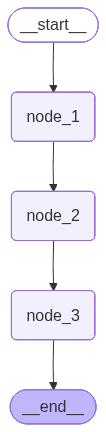

In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

# 상태 정의 
class DocumentState(TypedDict):
    query: str
    documents: List[str]

# Node 1: query 업데이트
def node_1(state: DocumentState) -> DocumentState:
    print("---Node 1 (query update)---")
    query = state["query"]
    return {"query": query}

# Node 2: 검색된 문서 추가 
def node_2(state: DocumentState) -> DocumentState:
    print("---Node 2 (add documents)---")
    return {"documents": ["doc1.pdf", "doc2.pdf", "doc3.pdf"]}

# Node 3: 추가적인 문서 검색 결과 추가
def node_3(state: DocumentState) -> DocumentState:
    print("---Node 3 (add more documents)---")
    return {"documents": ["doc2.pdf", "doc4.pdf", "doc5.pdf"]}


# 그래프 빌드
builder = StateGraph(DocumentState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 논리 구성
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

# 그래프 실행
graph = builder.compile()

graph


In [ ]:
#from IPython.display import Image, display
# 그래프 시각화
#display(Image(graph.get_graph().draw_mermaid_png()))

mermaid_code = graph.get_graph().draw_mermaid()
print("Mermaid Code:")
print(mermaid_code)

Mermaid Code:
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_1(node_1)
	node_2(node_2)
	node_3(node_3)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_1;
	node_1 --> node_2;
	node_2 --> node_3;
	node_3 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



* https://mermaid.live/ 에서  mermain_code 로 직접 확인한다.

* [Graph이미지](https://mermaidchart.com/play?utm_source=mermaid_live_editor&utm_medium=share#pako:eNpVkcFugzAMhl8FeZdWghacQmha9bI-wk4bU5VCUpAgoBCkdVXffWnoQD3Z_mT_v53cIG8LAQwumnel93HcZSozp1NvuLZh8bXvDlO1X3eH7yVjTFa6N49GZYdP0WIMy4ngSHAmZCRkOcoLVUziLp-kaz4qT6ZeEBy80WA3W84UZ4ozJTMljj59HM6tSX8U0iuE5ENtPFnVNXuTKEMp_bpSIihFdSkNi1b4MuAOd-1B2_G8MlcWvjQ81n_KneU5kTn49mmrApjkdS98aIRu-KOGW6Y8LwNTikZkwGz6XCeDTN3tXMfVZ9s2wIwe7KRuh0v5XwxdwY04Vtz-WzOJa3uj0O_toAwwjKnTAHaDH2DU3kJJiDHZJhHZbGMfrsCiTbpKE0y3GKdkQzG9-_DrTMMVpQQpYpQQDENC0_sffQK3NA)

In [3]:
# 질문
initial_state = {"query": "채식주의자를 위한 비건 음식을 추천해주세요."}

# 그래프 실행 
final_state = graph.invoke(initial_state)

# 최종 상태 출력
print("최종 상태:", final_state)

---Node 1 (query update)---
---Node 2 (add documents)---
---Node 3 (add more documents)---
최종 상태: {'query': '채식주의자를 위한 비건 음식을 추천해주세요.', 'documents': ['doc2.pdf', 'doc4.pdf', 'doc5.pdf']}


`(2) Reducer를 별도로 지정하는 경우 `
- `Annotated` 사용하여 지정한 reducer 작동 방식에 따라 기존 상태 정보를 업데이트 
- 리스트를 병합하는 `operator.add`를 사용하면, activity_log를 누적하는 방식으로 노드를 구현
- add 함수는 자체로 리스트를 병합하는 동작을 수행하지만, 이 동작이 LangGraph의 상태 병합 규칙으로 통합되려면 Annotated를 통해 해당 타입에 연결되어야 합니다. 

In [4]:
from operator import add # 항목들을 더하는 연산자(함수). 여기서는 리스트에 항목을 추가하는 용도로 사용됩니다.
from typing import Annotated, TypedDict # 타입 힌트에 메타데이터를 추가하는 Annotated와 딕셔너리 타입을 정의하는 TypedDict를 가져옵니다.
from langgraph.graph import StateGraph, START, END # LangGraph의 핵심 클래스들을 가져옵니다.

# ReducerState는 LangGraph의 에이전트 상태를 정의합니다.
# TypedDict를 사용하여 딕셔너리가 어떤 키와 값 타입을 가져야 하는지 명확하게 지정합니다.
class ReducerState(TypedDict):
    # 'query' 키는 단순 문자열 타입입니다.
    query: str
    # 'documents' 키는 문자열 리스트입니다.
    # 여기서 Annotated가 핵심 역할을 합니다. add를 메타데이터로 사용하여,
    # 'documents'에 새로운 리스트가 반환될 때마다 기존 리스트에 그 내용을
    # **추가(extend)**하도록 LangGraph에 지시합니다. 즉, 덮어쓰지 않습니다.
    documents: Annotated[List[str], add]

# Node 1: query 업데이트
# 이 함수는 에이전트의 첫 번째 노드 역할을 합니다.
def node_1(state: ReducerState) -> ReducerState:
    print("---Node 1 (query update)---")
    # 현재 상태에서 'query'를 가져와 반환합니다. 이 단계에서는 'documents'는 비어 있습니다.
    query = state["query"]
    return {"query": query}

# Node 2: 검색된 문서 추가
# 이 함수는 첫 번째 문서 세트를 반환합니다.
def node_2(state: ReducerState) -> ReducerState:
    print("---Node 2 (add documents)---")
    # 'documents' key에 리스트를 반환합니다.
    # Annotated[..., add] 지시 덕분에 이 리스트가 기존 'documents'에 추가됩니다.
    return {"documents": ["doc1.pdf", "doc2.pdf", "doc3.pdf"]}

# Node 3: 추가적인 문서 검색 결과 추가
# 이 함수는 두 번째 문서 세트를 반환합니다.
def node_3(state: ReducerState) -> ReducerState:
    print("---Node 3 (add more documents)---")
    # 'documents' 키에 또 다른 리스트를 반환합니다.
    # 이 리스트도 기존 'documents'에 추가됩니다.
    # 최종적으로 'documents'에는 두 노드에서 반환된 모든 문서가 포함됩니다.
    return {"documents": ["doc2.pdf", "doc4.pdf", "doc5.pdf"]}

# 그래프 빌드
builder = StateGraph(ReducerState)
# 세 개의 노드를 그래프에 추가합니다.
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 논리 구성 (그래프의 흐름을 정의)
# START에서 'node_1'로 시작합니다.
builder.add_edge(START, "node_1")
# 'node_1'에서 'node_2'로 진행합니다.
builder.add_edge("node_1", "node_2")
# 'node_2'에서 'node_3'으로 진행합니다.
builder.add_edge("node_2", "node_3")
# 'node_3'에서 END로 종료합니다.
builder.add_edge("node_3", END)

# 그래프 실행을 위해 컴파일합니다.
graph = builder.compile()

# 만약 이 그래프를 실행하면,
# 'documents'의 최종 상태는 ["doc1.pdf", "doc2.pdf", "doc3.pdf", "doc2.pdf", "doc4.pdf", "doc5.pdf"]가 됩니다.

In [5]:
# 초기 상태
initial_state = {"query": "채식주의자를 위한 비건 음식을 추천해주세요."}

# 그래프 실행 
final_state = graph.invoke(initial_state)

# 최종 상태 출력
print("최종 상태:", final_state)

---Node 1 (query update)---
---Node 2 (add documents)---
---Node 3 (add more documents)---
최종 상태: {'query': '채식주의자를 위한 비건 음식을 추천해주세요.', 'documents': ['doc1.pdf', 'doc2.pdf', 'doc3.pdf', 'doc2.pdf', 'doc4.pdf', 'doc5.pdf']}


`(3) Custom Reducer 사용 `
- 상태 업데이트가 기본적인 덮어쓰기나 병합만으로 해결되지 않을 때 유용한 방법
- 중복 제거, 최대/최소 값 유지, 조건부 병합 등의 특정 비즈니스 로직이 필요한 경우에 적용
- **커스텀 병합 함수(custom reducer)**를 사용하여 노드 간에 상태를 효율적으로 전달하는 방법을 보여줍니다. 
- Annotated를 사용해 특정 필드(documents)의 병합 방식을 기본 덮어쓰기 방식 대신 직접 정의한 함수로 지정합니다.

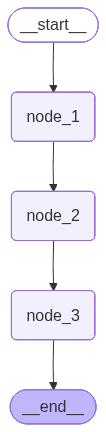

In [6]:
from typing import TypedDict, List, Annotated

# operator.add 대신 사용할 커스텀 병합 함수를 정의합니다.
# 이 함수는 두 리스트를 합치고 중복된 항목을 제거합니다.
def reduce_unique_documents(left: list | None, right: list | None) -> list:
    """두 문서 리스트를 합치고 중복을 제거합니다."""
    # left 또는 right가 None이면 빈 리스트로 초기화합니다.
    if not left:
        left = []
    if not right:
        right = []
    # 두 리스트를 합친 후, set으로 변환하여 중복을 제거하고 다시 리스트로 반환합니다.
    return list(set(left + right))

# LangGraph의 상태를 정의합니다.
class CustomReducerState(TypedDict):
    query: str
    # 'documents' 필드는 문자열 리스트입니다.
    # Annotated를 사용하여 이 필드에 새로운 값이 들어올 때,
    # 위에서 정의한 'reduce_unique_documents' 함수를 사용해
    # 기존 값과 새로운 값을 병합하도록 지시합니다.
    documents: Annotated[List[str], reduce_unique_documents]

# --- LangGraph 노드 정의 ---
# 이 노드들은 에이전트의 각 단계를 나타냅니다.
# Node 1: 쿼리를 업데이트합니다.
def node_1(state: CustomReducerState) -> CustomReducerState:
    print("---Node 1 (query update)---")
    query = state["query"]
    return {"query": query}

# Node 2: 첫 번째 문서 세트를 상태에 추가합니다.
def node_2(state: CustomReducerState) -> CustomReducerState:
    print("---Node 2 (add documents)---")
    return {"documents": ["doc1.pdf", "doc2.pdf", "doc3.pdf"]}

# Node 3: 두 번째 문서 세트를 상태에 추가합니다.
# 이 노드에서 반환된 "doc2.pdf"는 이미 존재하므로,
# reduce_unique_documents 함수에 의해 자동으로 제거됩니다.
def node_3(state: CustomReducerState) -> CustomReducerState:
    print("---Node 3 (add more documents)---")
    return {"documents": ["doc2.pdf", "doc4.pdf", "doc5.pdf"]}

# 그래프를 구성합니다.
builder = StateGraph(CustomReducerState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 그래프의 실행 흐름을 정의합니다.
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

# 최종 그래프를 컴파일합니다.
# 이 그래프를 실행하면, documents 필드는 노드 2와 3에서 반환된 모든 문서를 포함하되,
# 중복된 "doc2.pdf"는 제거됩니다.
graph = builder.compile()
graph

In [29]:
# 그래프 시각화
#display(Image(graph.get_graph().draw_mermaid_png()))

mermaid_code = graph.get_graph().draw_mermaid()
print("Mermaid Code:")
print(mermaid_code)

Mermaid Code:
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_1(node_1)
	node_2(node_2)
	node_3(node_3)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_1;
	node_1 --> node_2;
	node_2 --> node_3;
	node_3 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



* https://mermaid.live/ 에서  mermain_code 로 직접 확인한다.

* [Graph이미지](https://mermaidchart.com/play?utm_source=mermaid_live_editor&utm_medium=share#pako:eNpVkcFugzAMhl8FeZdWghacQmha9bI-wk4bU5VCUpAgoBCkdVXffWnoQD3Z_mT_v53cIG8LAQwumnel93HcZSozp1NvuLZh8bXvDlO1X3eH7yVjTFa6N49GZYdP0WIMy4ngSHAmZCRkOcoLVUziLp-kaz4qT6ZeEBy80WA3W84UZ4ozJTMljj59HM6tSX8U0iuE5ENtPFnVNXuTKEMp_bpSIihFdSkNi1b4MuAOd-1B2_G8MlcWvjQ81n_KneU5kTn49mmrApjkdS98aIRu-KOGW6Y8LwNTikZkwGz6XCeDTN3tXMfVZ9s2wIwe7KRuh0v5XwxdwY04Vtz-WzOJa3uj0O_toAwwjKnTAHaDH2DU3kJJiDHZJhHZbGMfrsCiTbpKE0y3GKdkQzG9-_DrTMMVpQQpYpQQDENC0_sffQK3NA)

In [7]:
# 초기 상태
initial_state = {"query": "채식주의자를 위한 비건 음식을 추천해주세요.", "documents": []}

# 그래프 실행 
final_state = graph.invoke(initial_state)

# 최종 상태 출력
print("최종 상태:", final_state)

---Node 1 (query update)---
---Node 2 (add documents)---
---Node 3 (add more documents)---
최종 상태: {'query': '채식주의자를 위한 비건 음식을 추천해주세요.', 'documents': ['doc5.pdf', 'doc4.pdf', 'doc1.pdf', 'doc2.pdf', 'doc3.pdf']}


#### 2. MessageGraph 역할
* MessageGraph는 **채팅 및 대화형 애플리케이션**을 구축하는 데 특화된 그래프 클래스입니다. 
    * 일반적인 StateGraph가 딕셔너리 기반의 상태를 관리하는 반면, MessageGraph는 대화의 흐름을 나타내는 **메시지 목록(list[messages])**을 핵심 상태로 사용합니다. 
    * 이를 통해 사용자와 AI 간의 상호작용을 자연스럽게 모델링하고 관리할 수 있습니다.

* MessageGraph는 다음과 같은 주요 기능을 제공합니다.
    * 메시지 기반 상태 관리: 상태를 messages라는 키를 가진 리스트로 자동 설정하여, 사용자와 AI의 대화 기록을 손쉽게 추적할 수 있습니다.
    * MessageGraph는 대화 상태를 자동으로 messages 리스트로 관리하므로, 각 노드 함수는 새로운 메시지를 반환하기만 하면 됩니다.
    * 자동 병합: 각 노드에서 새로운 메시지 목록을 반환하면, MessageGraph는 이를 기존 메시지 목록에 자동으로 추가(append)합니다. 
        * 이는 StateGraph에서 Annotated와 add를 사용해 수동으로 구현해야 했던 기능을 기본적으로 제공합니다.
    * 대화 중심 흐름: 대화형 에이전트의 작동 방식을 직관적으로 표현합니다. 한 노드에서 사용자 메시지를 처리하고, 다른 노드에서 AI 응답을 생성하는 등 대화의 각 단계를 명확하게 구분할 수 있습니다.

`(1) Messages State 정의`
- 이전 대화 기록을 그래프 상태에 메시지 목록으로 저장하는 것이 유용
- 그래프 상태에 Message 객체 목록을 저장하는 키(채널)를 추가하고, 이 키에 리듀서 함수를 추가 
- 리듀서 함수 선택:
    - operator.add를 사용하면: 새 메시지를 기존 목록에 단순히 추가
    - add_messages 함수를 사용하면:
        - 새 메시지는 기존 목록에 추가
        - 기존 메시지 업데이트도 올바르게 처리 (메시지 ID를 추적)
```python
class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]        
```    

##### 1) 기본 State 초기화 방법을 사용

In [31]:
from typing import Annotated,TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# 기본 State 초기화 방법을 사용
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

##### 2) MessagesState 상태 객체를 사용

In [ ]:
# LangGraph MessagesState라는 미리 만들어진 상태를 사용
from langgraph.graph import MessagesState
from typing import List
from langchain_core.documents import Document

class GraphState(MessagesState):
    # messages key는 기본적으로 제공 - 다른 키를 추가하고 싶을 경우 아래 주석과 같이 적용 가능 
    documents: List[Document]
    grade: float
    num_generation: int

In [26]:
from dotenv import load_dotenv
import os

# .env 파일을 불러와서 환경 변수로 설정
load_dotenv()

UPSTAGE_API_KEY = os.getenv("UPSTAGE_API_KEY")
print(UPSTAGE_API_KEY[30:])

NY


In [28]:
from langchain_upstage import ChatUpstage

llm = ChatUpstage(
        model="solar-pro",
        base_url="https://api.upstage.ai/v1",
        temperature=0.5
    )
print(llm.model_name)

solar-pro


##### 기본적인 MessagesState 사용

In [29]:
from typing import List, Dict, Any
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate

# MessagesState 정의
class MessagesState(Dict[str, Any]):
    messages: List[BaseMessage]

 # AI 응답 생성 노드
def generate_response(state: MessagesState) -> Dict[str, Any]:
    # 시스템 프롬프트와 메시지 기록을 결합
    prompt = ChatPromptTemplate.from_messages([
        ("system", "당신은 친절한 AI 어시스턴트입니다. 사용자의 질문에 친절하게 답변해주세요."),
        *[(msg.type, msg.content) for msg in state["messages"]]
    ])
    
    # 체인 생성
    chain = prompt | llm
    
    # 응답 생성
    response = chain.invoke({})
    
    # 새로운 메시지를 상태에 추가
    return {"messages": [response]}

# 그래프 빌더 생성
graph_builder = StateGraph(MessagesState)

# 노드 추가
graph_builder.add_node("generate", generate_response)

# 엣지 설정
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

# 그래프 컴파일
app = graph_builder.compile()


In [ ]:

# 실행 예제
if __name__ == "__main__":
    # 초기 메시지로 그래프 실행
    initial_state = MessagesState(messages=[HumanMessage(content="안녕하세요! 오늘 날씨가 어때요?")])
    result = app.invoke(initial_state)
    
    print("AI 응답:", result["messages"][-1].content)
    
    # 대화 계속 이어가기
    next_state = MessagesState(messages=[
        HumanMessage(content="안녕하세요! 오늘 날씨가 어때요?"),
        result["messages"][-1],
        HumanMessage(content="서울 날씨는 specifically 어떻게 될까요?")
    ])
    
    next_result = app.invoke(next_state)
    print("두 번째 AI 응답:", next_result["messages"][-1].content)   

#### 조금 더 복잡한 대화 흐름

In [32]:
from typing import List, Dict, Any
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

class MessagesState(Dict[str, Any]):
    messages: List[BaseMessage]
    user_name: str = "사용자"

In [33]:

# 사용자 이름 추출 노드
def extract_name(state: MessagesState) -> Dict[str, Any]:
    last_message = state["messages"][-1].content.lower()
    
    # 간단한 이름 추출 로직 (실제로는 더 정교하게 구현)
    if "이름은" in last_message or "제 이름은" in last_message:
        for word in last_message.split():
            if "은" in word or "는" in word:
                name = word.replace("은", "").replace("는", "").strip()
                if len(name) > 1:  # 실제 이름일 가능성이 있는 경우
                    return {"user_name": name}
    
    return {"user_name": state.get("user_name", "사용자")}

# AI 응답 생성 노드
def generate_response(state: MessagesState) -> Dict[str, Any]:
    user_name = state.get("user_name", "사용자")
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", f"당신은 친절한 AI 어시스턴트입니다. 사용자 {user_name}의 질문에 친절하게 답변해주세요."),
        *[(msg.type, msg.content) for msg in state["messages"]]
    ])
    
    chain = prompt | llm
    response = chain.invoke({})
    
    return {"messages": [response]}

In [34]:

# 그래프 구성
graph_builder = StateGraph(MessagesState)

# 노드 추가
graph_builder.add_node("extract_name", extract_name)
graph_builder.add_node("generate", generate_response)

# 엣지 설정
graph_builder.add_edge(START, "extract_name")
graph_builder.add_edge("extract_name", "generate")
graph_builder.add_edge("generate", END)

# 그래프 컴파일
app = graph_builder.compile()

# 실행
if __name__ == "__main__":
    # 첫 번째 대화
    initial_state = MessagesState(
        messages=[HumanMessage(content="안녕하세요, 제 이름은 김철수입니다. 오늘 날씨가 어때요?")]
    )
    
    result = app.invoke(initial_state)
    print("사용자 이름:", result.get("user_name", "알 수 없음"))
    print("AI 응답:", result["messages"][-1].content)

사용자 이름: 이름
AI 응답: 안녕하세요, 김철수님! 😊  
오늘은 날씨가 [현재 위치 기반 날씨 정보]를 확인할 수 없어 정확한 답변을 드리기 어렵습니다.  

다만, **실시간 날씨**를 확인하는 방법을 안내해 드릴게요!  
1. 스마트폰 기본 날씨 앱 또는 **네이버/다음 날씨** 검색  
2. "날씨" + [현재 지역명] 예) "서울 날씨"로 검색  
3. 기상청 앱 또는 웹사이트(www.weather.go.kr)  

혹시 특정 지역의 날씨가 궁금하시면 알려주세요! 최대한 도와드릴게요. ☀️🌧️  

좋은 하루 보내세요! 😊


#### 조건부 분기를 포함한 예제

In [36]:
from typing import List, Dict, Any, Literal
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

class MessagesState(Dict[str, Any]):
    messages: List[BaseMessage]
    conversation_topic: str = "일반"

In [37]:

# 대화 주제 분류 노드
def classify_topic(state: MessagesState) -> Dict[str, Any]:
    last_message = state["messages"][-1].content.lower()
    
    if any(word in last_message for word in ["날씨", "기온", "날씨"]):
        return {"conversation_topic": "날씨"}
    elif any(word in last_message for word in ["음식", "식사", "맛집"]):
        return {"conversation_topic": "음식"}
    elif any(word in last_message for word in ["영화", "드라마", "영화"]):
        return {"conversation_topic": "영화"}
    else:
        return {"conversation_topic": "일반"}

# 주제별 응답 생성
def generate_weather_response(state: MessagesState) -> Dict[str, Any]:
    prompt = ChatPromptTemplate.from_messages([
        ("system", "당신은 날씨 전문가입니다. 정확한 날씨 정보를 제공해주세요."),
        *[(msg.type, msg.content) for msg in state["messages"]]
    ])
    
    chain = prompt | llm
    response = chain.invoke({})
    return {"messages": [response]}

def generate_food_response(state: MessagesState) -> Dict[str, Any]:
    prompt = ChatPromptTemplate.from_messages([
        ("system", "당신은 음식 전문가입니다. 맛있는 음식 추천을 해주세요."),
        *[(msg.type, msg.content) for msg in state["messages"]]
    ])
    
    chain = prompt | llm
    response = chain.invoke({})
    return {"messages": [response]}

def generate_general_response(state: MessagesState) -> Dict[str, Any]:
    prompt = ChatPromptTemplate.from_messages([
        ("system", "당신은 친절한 AI 어시스턴트입니다."),
        *[(msg.type, msg.content) for msg in state["messages"]]
    ])
    
    chain = prompt | llm
    response = chain.invoke({})
    return {"messages": [response]}

# 다음 노드 결정 함수
def decide_next_node(state: MessagesState) -> Literal["weather", "food", "general"]:
    topic = state.get("conversation_topic", "일반")
    
    if topic == "날씨":
        return "weather"
    elif topic == "음식":
        return "food"
    else:
        return "general"


In [38]:

# 그래프 구성
graph_builder = StateGraph(MessagesState)

# 노드 추가
graph_builder.add_node("classify", classify_topic)
graph_builder.add_node("weather", generate_weather_response)
graph_builder.add_node("food", generate_food_response)
graph_builder.add_node("general", generate_general_response)

# 엣지 설정
graph_builder.add_edge(START, "classify")
graph_builder.add_conditional_edges(
    "classify",
    decide_next_node,
    {
        "weather": "weather",
        "food": "food",
        "general": "general"
    }
)
graph_builder.add_edge("weather", END)
graph_builder.add_edge("food", END)
graph_builder.add_edge("general", END)

# 그래프 컴파일
app = graph_builder.compile()

# 실행
if __name__ == "__main__":
    test_messages = [
        "오늘 서울 날씨는 어때?",
        "점심에 먹을만한 음식 추천해줘",
        "안녕하세요!"
    ]
    
    for message in test_messages:
        state = MessagesState(messages=[HumanMessage(content=message)])
        result = app.invoke(state)
        topic = result.get("conversation_topic", "일반")
        response = result["messages"][-1].content
        
        print(f"입력: {message}")
        print(f"주제: {topic}")
        print(f"응답: {response}")
        print("-" * 50)

입력: 오늘 서울 날씨는 어때?
주제: 날씨
응답: 현재(2023년 10월 기준) 실시간 날씨 정보를 제공할 수는 없지만, 서울 날씨 확인 방법을 안내해 드리겠습니다.  

### 📱 **실시간 서울 날씨 확인 방법**  
1. **기상청 날씨누리** ([www.weather.go.kr](https://www.weather.go.kr))  
   - "서울" 지역 검색 후 현재 온도, 강수 확률, 습도, 풍속 등 상세 정보 확인 가능.  
   - 시간별/주간 예보 제공.  

2. **날씨 앱** (예: **AccuWeather**, **The Weather Channel**, **케이웨더**)  
   - 실시간 업데이트 및 미세먼지, 자외선 지수 등 추가 정보 제공.  

3. **검색 엔진** (Google, Naver)  
   - "서울 날씨" 검색 시 현재 상태, 최고/최저 온도, 예보 요약이 표시됩니다.  

### 🌦️ **10월 서울 평균 날씨 참고**  
- **평균 기온**: 10~20°C (낮에는 선선하고 아침/저녁으로 쌀쌀함)  
- **특징**: 맑고 건조한 날이 많으나, 갑작스러운 비나 일교차 큰 날이 있을 수 있음.  

실시간 정보는 위의 방법으로 확인해 주세요! ☀️🌧️
--------------------------------------------------
입력: 점심에 먹을만한 음식 추천해줘
주제: 음식
응답: 점심에 먹기 좋은 맛있는 음식을 추천해드릴게요! 계절과 기분에 따라 다양한 옵션을 준비했으니 참고하세요 😊  

### 🍜 **한식 추천**  
- **비빔밥** : 영양 균형 + 밥도둑 반찬과 함께  
- **김치찌개 + 공기밥** : 구수한 국물과 밥 한 그릇  
- **제육덮밥** : 매콤달콤한 고기 덮밥으로 에너지 충전  
- **순두부찌개** : 부드럽고 담백한 맛 (매운맛/청양고추 추가 가능)  

### 🌮 **양식/퓨전 추천**  
- **파스타 (크림리조또/알리오 올리오)** : 간단한 면 요리로 